In [1]:
#importing packages
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from matplotlib import pyplot

In [2]:
#loading dataset
def load_dataset(fname):
    data=read_csv(fname,header=None)
    dataset=data.values
    X=dataset[:,:-1]
    y=dataset[:,-1]
    return X,y

In [3]:
#Train Test split
X,y=load_dataset('E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\pima-indians-diabetes.csv')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=1)
print('Train',X_train.shape,y_train.shape)
print('Test',X_test.shape,y_test.shape)

Train (514, 8) (514,)
Test (254, 8) (254,)


In [4]:
#ANOVA F_statistic score based feature selection
def select_features(X_train,y_train,X_test):
    fs=SelectKBest(score_func=f_classif,k=4)
    fs.fit(X_train,y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs,X_test_fs,fs

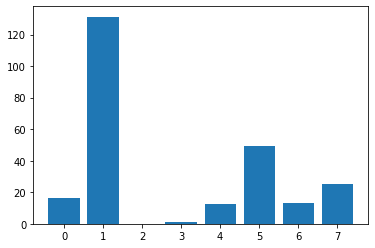

In [5]:
#Selecting best features and plotting
X_train_fs,X_test_fs,fs=select_features(X_train,y_train,X_test)
pyplot.bar([i for i in range(len(fs.scores_))],fs.scores_)
pyplot.show()

In [6]:
#feature scores
fs.scores_

array([1.65273845e+01, 1.31325562e+02, 4.23711464e-02, 1.41521551e+00,
       1.27789661e+01, 4.92095231e+01, 1.33771423e+01, 2.51264397e+01])

In [14]:
from sklearn.feature_selection import mutual_info_classif

In [15]:
#Mutual information based feature selection
def select_features_2(X_train,y_train,X_test):
    fs=SelectKBest(score_func=mutual_info_classif,k=4)
    fs.fit(X_train,y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs,X_test_fs,fs

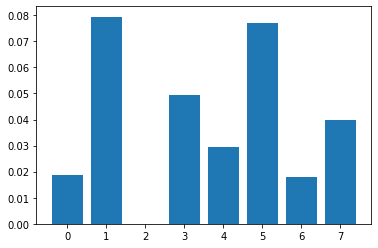

In [16]:
#Selecting best features using MI and plotting
X_train_fs2,X_test_fs2,fs2=select_features_2(X_train,y_train,X_test)
pyplot.bar([i for i in range(len(fs2.scores_))],fs2.scores_)
pyplot.show()

In [17]:
#feature scores
fs2.scores_

array([0.01876784, 0.0794209 , 0.        , 0.04925937, 0.02957884,
       0.07715796, 0.01779686, 0.03976598])

In [7]:
#Building model with all features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [8]:
model1=LogisticRegression(solver='liblinear')
model1.fit(X_train,y_train)
yhat=model1.predict(X_test)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 77.56


In [9]:
#Model built using features chosen with ANOVA F-statistic
model2=LogisticRegression(solver='liblinear')
model2.fit(X_train_fs,y_train)
yhat=model2.predict(X_test_fs)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 78.74


In [18]:
#Model built using features chosen with Mutual information
model3=LogisticRegression(solver='liblinear')
model3.fit(X_train_fs2,y_train)
yhat=model3.predict(X_test_fs2)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 75.98


In [19]:
#Tune the number of selected features -grid search
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV


In [20]:
#define the data set
X,y=load_dataset('E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\pima-indians-diabetes.csv')

In [21]:
#define the evaluation method - k-fold cross validation & k=10
cv=RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=1)


In [41]:
#define the pipeline to evaluate
model=LogisticRegression(solver='liblinear')
fs=SelectKBest(score_func=f_classif)
pipeline=Pipeline(steps=[('anova',fs),('lr',model)])

In [42]:
#define the grid
grid=dict()
grid['anova__k']=[i+1 for i in range(X.shape[1])]

In [43]:
#define the grid search
search=GridSearchCV(pipeline, grid, scoring='accuracy',n_jobs=-1, cv=cv)
results=search.fit(X,y)

In [44]:
print('Best Mean Accuracy: %.3f' % results.best_score_)
print('Best config %s' %results.best_params_)

Best Mean Accuracy: 0.770
Best config {'anova__k': 7}


The results shows that the no. of best features is 7 and the mean accuracy with 7 features is 0.77

In [45]:
#comparing different no. of features selected using ANOVA f-test
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_val_score

In [46]:
def evaluate_model(pipeline):
    cv=RepeatedStratifiedKFold(n_repeats=3,n_splits=10, random_state=1)
    scores=cross_val_score(pipeline,X,y,scoring='accuracy',cv=cv,n_jobs=1)
    return scores

#1 0.748 (0.048)
#2 0.756 (0.042)
#3 0.761 (0.044)
#4 0.759 (0.042)
#5 0.770 (0.041)
#6 0.766 (0.042)
#7 0.770 (0.042)
#8 0.768 (0.040)


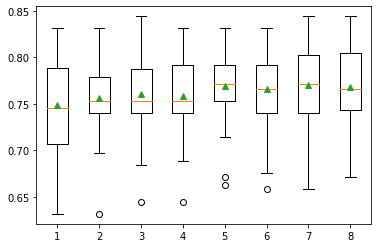

In [48]:
#define the data set
X,y=load_dataset('E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\pima-indians-diabetes.csv')

#define the no. of features
num_features=[i+1 for i in range(X.shape[1])]

#enumerate each no. of feature
results=list()
for k in num_features:
    #create pipeline
    model=LogisticRegression(solver='liblinear')
    fs=SelectKBest(score_func=f_classif,k=k)
    pipeline=Pipeline(steps=[('anova',fs),('lr',model)])
    
    #evaluate the model
    scores=evaluate_model(pipeline)
    results.append(scores)
    
    print('#%d %.3f (%.3f)' %(k,mean(scores),std(scores)))
pyplot.boxplot(results, labels=num_features, showmeans=True)
pyplot.show()